# 02 — Data dictionary · **EXPLORE**

**Owner:** Jaime · **Status:** sandbox · **Reading order:** after `00` (selection) and `01` (ingestion)

**What this is.** A *self-generating* map of what data exist and what each object can answer — every table and plot
below is produced from the real dataset by `ingestion.py`, so it cannot drift from reality. Built to be scanned:
tables and figures, minimal prints.

**Provenance.** Base dataset = `hcp_task_with_behaviour` (100 subjects), OSF → `data/hcp_task/`. Parcellation:
Glasser et al. 2016. Networks: Ji et al. 2019 (Cole-Anticevic). The `Stats.txt` behaviour parser is ours.

## 1. Setup and constants

In [1]:
from pathlib import Path
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd/"sandbox").exists() else (cwd.parents[1] if cwd.name=="jaime" else cwd)
sys.path.insert(0, str(ROOT/"sandbox"/"jaime"))
import ingestion as ing
HCP_DIR = Path(os.environ.get("GAMMAS_DATA_DIR", ROOT/"data"))/"hcp_task"
subjects = ing.get_subjects(HCP_DIR)
plt.rcParams.update({"figure.dpi":110,"font.size":9,"axes.spines.top":False,"axes.spines.right":False})

pd.DataFrame({"value":[ing.N_SUBJECTS, ing.N_PARCELS, ing.TR, ", ".join(ing.RUNS)]},
             index=["N_SUBJECTS","N_PARCELS","TR (s)","runs"])

             value
N_SUBJECTS     100
N_PARCELS      360
TR (s)        0.72
runs        LR, RL

## 2. Data objects — the schema you load

| Object | Shape / type | What it is | Loader |
|---|---|---|---|
| `regions.npy` → region table | 360 rows | ROI name, network, hemisphere | `build_region_table` |
| `data.npy` | `(360 × frames)` | parcellated BOLD, mean-removed | `load_single_timeseries` |
| `EVs/<cond>.txt` | `(onset, dur, amp)` | condition timing (seconds) | `load_condition_frames` |
| `EVs/Stats.txt` | `label: value` | behaviour per run (ACC, RT) | `parse_stats` / `load_behaviour` |


In [2]:
ts = ing.load_single_timeseries(HCP_DIR, subjects[0], "WM", 0)
m0 = ing.load_condition_timeseries(HCP_DIR, subjects[0], "0back")
pd.DataFrame({"shape":[str(ts.shape), str(m0.shape)],
              "meaning":["one WM run (ROIs × frames)","per-condition BOLD → step 3 (LR+RL)"]},
             index=["load_single_timeseries","load_condition_timeseries"])

                                shape                              meaning
load_single_timeseries     (360, 405)           one WM run (ROIs × frames)
load_condition_timeseries  (360, 312)  per-condition BOLD → step 3 (LR+RL)

## 3. The 360 ROIs → 12 networks

Generated from `regions.npy`. **Gotcha (documented):** network labels are stored **truncated to 12 characters**;
`ingestion.NETWORK_FULL` de-truncates them to the published Ji (2019) names. Both columns are kept.

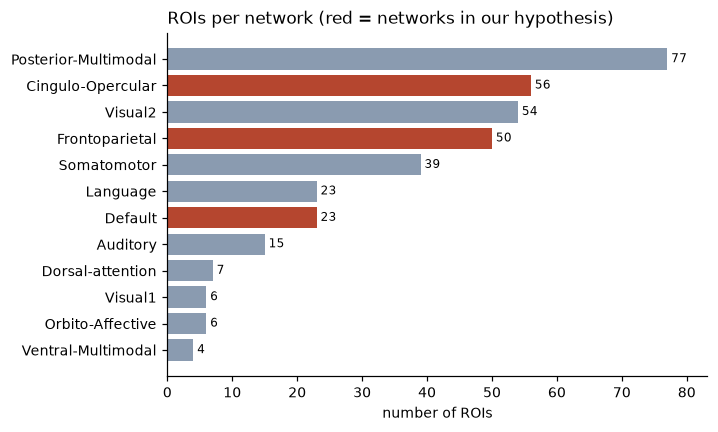

In [3]:
reg = ing.build_region_table(HCP_DIR)
counts = reg.groupby("network").size().sort_values()
focus = {"Frontoparietal","Default","Cingulo-Opercular"}   # networks the hypothesis cares about

fig, ax = plt.subplots(figsize=(6.6, 4.0))
colors = ["#b5462f" if n in focus else "#8a9bb0" for n in counts.index]
ax.barh(counts.index, counts.values, color=colors)
for i,(n,v) in enumerate(counts.items()):
    ax.text(v+0.6, i, str(v), va="center", fontsize=8)
ax.set_xlabel("number of ROIs"); ax.margins(x=0.08)
ax.set_title("ROIs per network (red = networks in our hypothesis)", loc="left")
fig.tight_layout(); fig.savefig("fig02_networks.png", dpi=130); plt.show()

The three networks central to the hypothesis — **Frontoparietal (50), Cingulo-Opercular (56), Default (23)** —
are all well represented. Note: this atlas has **no "Salience" label**; Cingulo-Opercular is its functional
equivalent.

## 4. The WM task — conditions

8 conditions = 2 load levels × 4 stimulus categories. `Stats.txt` labels the body category **"BP"** (Body Parts).

In [4]:
pd.DataFrame({"0-back": list(ing.COND_0BACK), "2-back": list(ing.COND_2BACK),
              "Stats.txt category": list(ing.STATS_CATEGORIES)})

       0-back      2-back Stats.txt category
0    0bk_body    2bk_body                 BP
1   0bk_faces   2bk_faces              Faces
2  0bk_places  2bk_places             Places
3   0bk_tools   2bk_tools              Tools

## 5. The prediction target — dictionary and distribution

`load_behaviour` derives per-subject targets from `Stats.txt`. `acc_2bk` is the recommended primary target.

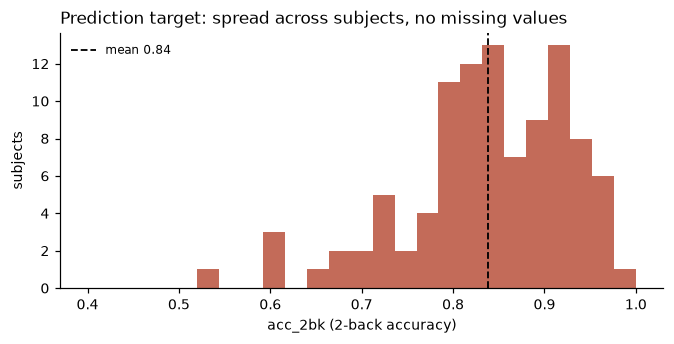

In [5]:
beh = ing.behaviour_table(HCP_DIR, subjects)
fig, ax = plt.subplots(figsize=(6.2, 3.2))
ax.hist(beh.acc_2bk, bins=np.linspace(0.4,1,26), color="#b5462f", alpha=0.8)
ax.axvline(beh.acc_2bk.mean(), color="k", lw=1.2, ls="--", label=f"mean {beh.acc_2bk.mean():.2f}")
ax.set_xlabel("acc_2bk (2-back accuracy)"); ax.set_ylabel("subjects")
ax.set_title("Prediction target: spread across subjects, no missing values", loc="left")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig("fig02_target.png", dpi=130); plt.show()

In [6]:
target_dict = pd.DataFrame([
    ("acc_2bk", "mean accuracy, 2-back", "recommended target — spans ~0.54–0.99"),
    ("acc_0bk", "mean accuracy, 0-back", "near-ceiling (~0.93), poor discriminator"),
    ("acc_cost","acc_2bk − acc_0bk",     "load cost (negative = worse under load)"),
    ("rt_2bk / rt_0bk / rt_cost", "median reaction times (ms)", "alternative / covariate"),
], columns=["column","meaning","note"]).set_index("column")
target_dict

                                              meaning                                      note
column                                                                                         
acc_2bk                         mean accuracy, 2-back     recommended target — spans ~0.54–0.99
acc_0bk                         mean accuracy, 0-back  near-ceiling (~0.93), poor discriminator
acc_cost                            acc_2bk − acc_0bk   load cost (negative = worse under load)
rt_2bk / rt_0bk / rt_cost  median reaction times (ms)                   alternative / covariate

## 6. Reproducible `inspect()` — validate any fresh download in seconds

In [7]:
def inspect(hcp_dir, subjects):
    reg = ing.build_region_table(hcp_dir)
    beh = ing.behaviour_table(hcp_dir, subjects)
    ts  = ing.load_single_timeseries(hcp_dir, subjects[0], "WM", 0)
    m0  = ing.load_condition_timeseries(hcp_dir, subjects[0], "0back")
    return pd.DataFrame({"value":[
        len(subjects), f"{reg.shape} · {reg.network.nunique()} networks",
        str(ts.shape), str(m0.shape),
        f"{beh.shape} · {int(beh.acc_2bk.isna().sum())} missing",
        f"{beh.acc_2bk.min():.3f}–{beh.acc_2bk.max():.3f}"]},
        index=["subjects","region table","BOLD (1 run)","per-condition BOLD","behaviour","acc_2bk range"])

inspect(HCP_DIR, subjects)

                                     value
subjects                               100
region table        (360, 5) · 12 networks
BOLD (1 run)                    (360, 405)
per-condition BOLD              (360, 312)
behaviour             (100, 7) · 0 missing
acc_2bk range                  0.537–0.988

## 7. What each object can / cannot answer

| Resource | ✅ Good for | ❌ Not for |
|---|---|---|
| WM `data.npy` + EVs | per-condition FC, 0→2-back reconfiguration | resting-state (absent in this loader) |
| `Stats.txt` | WM performance target (ACC/RT) | fine trial-level modelling |
| `hcp` loader (339 subj) | real resting-state FC + more subjects | different subject IDs; see `00` |

**Closed:** target `acc_2bk`; 312 frames/condition; truncated network labels handled. **Open (team):**
dataset A vs B (`00`), graph thresholding, prediction model.